# EDA: ข้อมูลรถมือสอง (CarDekho)

สำรวจข้อมูลดิบก่อนเทรนโมเดล ตอบ 4 คำถาม:
1. ข้อมูลมีขนาดเท่าไร มีค่าหายหรือแถวซ้ำไหม
2. ราคาขายกระจายตัวอย่างไร
3. ปี เลขไมล์ เชื้อเพลิง เกียร์ มีความสัมพันธ์กับราคาอย่างไร
4. ผลที่ได้อธิบายการออกแบบ pipeline (แบ่งข้อมูลตามปี, ลบข้อมูลซ้ำ, ทำความสะอาดหน่วย) อย่างไร

ต้องรัน `python scripts/download_data.py` (หรือ `python -m src.pipeline`) ก่อน เพื่อให้มีไฟล์ `data/raw/car_details_v3.csv`

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="Glyph")
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (8, 4)

# notebook อยู่ในโฟลเดอร์ notebooks/ จึงต้องถอยขึ้นหนึ่งระดับ
df = pd.read_csv("../data/raw/car_details_v3.csv")
print(df.shape)
df.head()

(8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 1. ภาพรวม: ชนิดข้อมูล ค่าหาย แถวซ้ำ

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [3]:
# จำนวนและสัดส่วนค่าหายต่อคอลัมน์
missing = df.isna().sum().to_frame("missing")
missing["percent"] = (missing["missing"] / len(df) * 100).round(2)
missing[missing["missing"] > 0]

,missing,percent
mileage,221,2.72
engine,221,2.72
max_power,215,2.65
torque,222,2.73
seats,221,2.72


In [4]:
dup = df.duplicated().sum()
print(f"แถวซ้ำ: {dup} จาก {len(df)} ({dup/len(df):.1%})")
print(f"หลังลบซ้ำ: {len(df.drop_duplicates())} แถว")
df = df.drop_duplicates().reset_index(drop=True)

แถวซ้ำ: 1202 จาก 8128 (14.8%)
หลังลบซ้ำ: 6926 แถว


**สังเกต:** มีแถวซ้ำจำนวนมาก ถ้าไม่ลบก่อนแบ่ง train/test แถวเดียวกันอาจไปอยู่ทั้งสองฝั่ง ทำให้คะแนนทดสอบดูดีเกินจริง (data leakage) จึงลบซ้ำก่อนแบ่งข้อมูล

## 2. การกระจายของราคาขาย

count        6926.0
mean       517271.0
std        519767.0
min         29999.0
25%        250000.0
50%        400000.0
75%        633500.0
max      10000000.0
Name: selling_price, dtype: float64


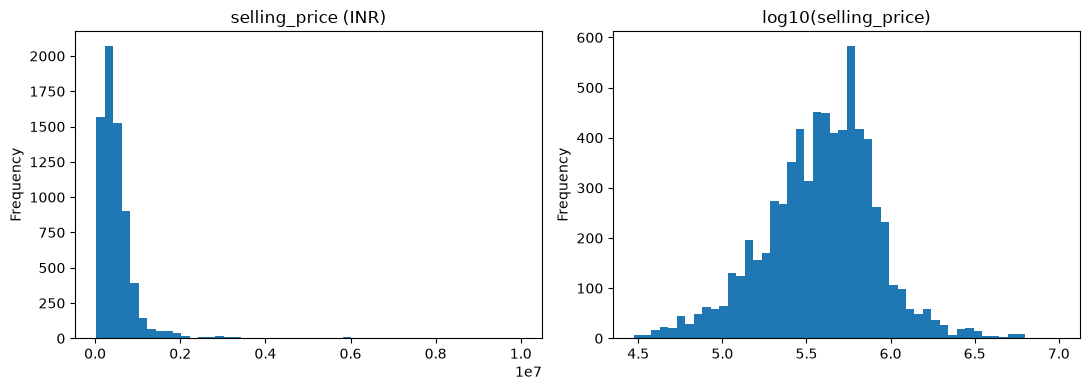

In [5]:
print(df["selling_price"].describe().round(0))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df["selling_price"].plot.hist(bins=50, ax=ax[0], title="selling_price (INR)")
np.log10(df["selling_price"]).plot.hist(bins=50, ax=ax[1], title="log10(selling_price)")
plt.tight_layout()
plt.show()

**สังเกต:** ราคาเบ้ขวาชัดเจน (รถหรูไม่กี่คันดึงค่าเฉลี่ยขึ้น) หลังแปลง log จะใกล้รูประฆังมากขึ้น ซึ่ง `src/train.py` ใช้ประโยชน์จากข้อนี้อยู่แล้วด้วย `TransformedTargetRegressor` (เทรนบน log1p ของราคาแล้วแปลงกลับด้วย expm1) และ baseline ใช้ **median** แทน mean

## 3. ราคากับปีที่ผลิต

,count,median
year,,
2009,240,180000.0
2010,380,220000.0
2011,554,265000.0
2012,604,310000.0
2013,562,387000.0
2014,581,450000.0
2015,681,525000.0
2016,693,550000.0
2017,808,625000.0


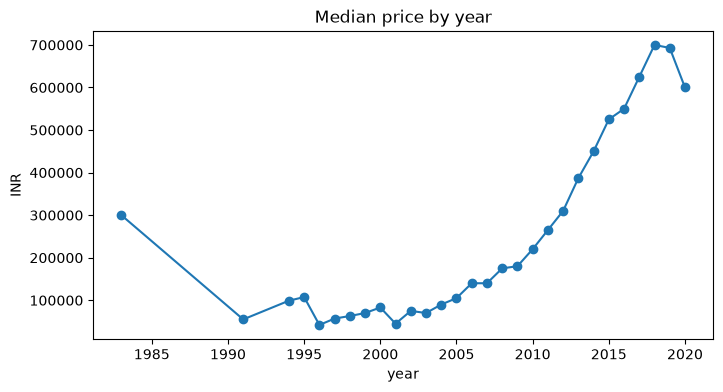

In [6]:
by_year = df.groupby("year")["selling_price"].agg(["count", "median"])
display(by_year.tail(12))

by_year["median"].plot(marker="o", title="Median price by year")
plt.ylabel("INR")
plt.show()

**สังเกต:** ราคากลางสูงขึ้นตามปีที่ผลิตจนถึงปี 2018 (700,000 รูปี) แต่ปี 2019 (693,000) และ 2020 (600,000) ลดลง และมีข้อมูลน้อยมาก (2019 มี 347 คัน, 2020 มีเพียง 63 คัน) จำนวนรถต่อปีสูงสุดที่ปี 2017 (808 คัน) แล้วลดลง

ข้อมูลนี้สัมพันธ์กับการแบ่ง train ≤ 2016 / val = 2017 / test ≥ 2018 ของโปรเจกต์ ซึ่งจำลองสถานการณ์ใช้งานจริงที่ต้องทำนายรถรุ่นใหม่กว่าที่โมเดลเคยเห็น และช่วยอธิบายว่าทำไม pipeline ตรวจพบ data drift และ concept drift

## 4. ราคากับตัวแปรหมวดหมู่

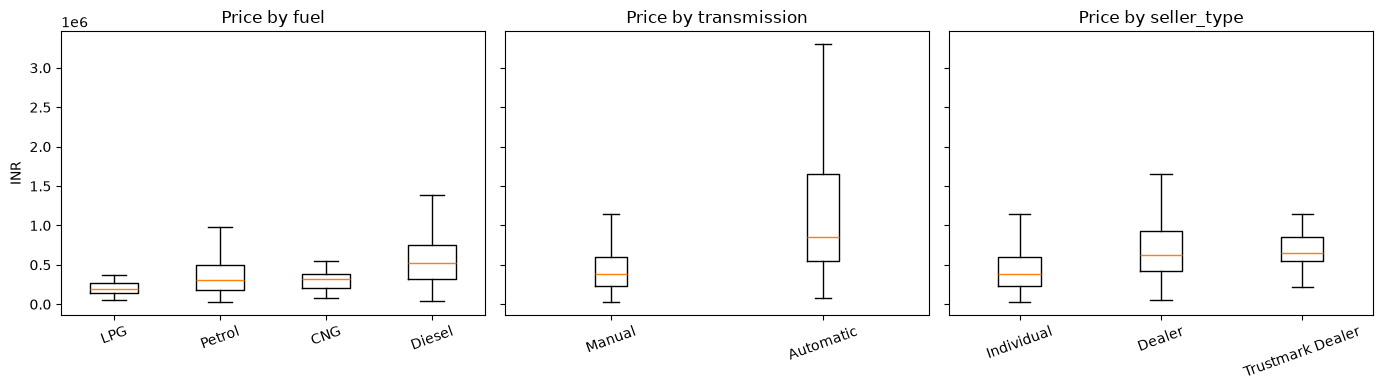

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, ["fuel", "transmission", "seller_type"]):
    order = df.groupby(col)["selling_price"].median().sort_values().index
    data = [df.loc[df[col] == k, "selling_price"] for k in order]
    ax.boxplot(data, tick_labels=order, showfliers=False)
    ax.set_title(f"Price by {col}")
    ax.tick_params(axis="x", rotation=20)
axes[0].set_ylabel("INR")
plt.tight_layout()
plt.show()

In [8]:
df["owner"].value_counts()

owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64

## 5. ราคากับเลขไมล์

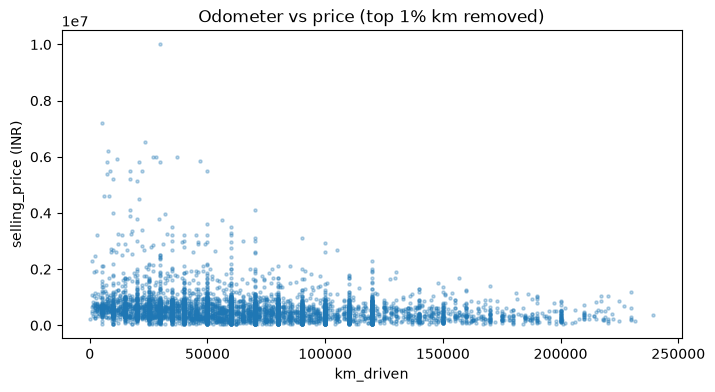

correlation (Spearman) year vs price : 0.705
correlation (Spearman) km vs price   : -0.289


In [9]:
sample = df[df["km_driven"] < df["km_driven"].quantile(0.99)]
plt.scatter(sample["km_driven"], sample["selling_price"], s=5, alpha=0.3)
plt.xlabel("km_driven")
plt.ylabel("selling_price (INR)")
plt.title("Odometer vs price (top 1% km removed)")
plt.show()

print("correlation (Spearman) year vs price :", round(df["year"].corr(df["selling_price"], method="spearman"), 3))
print("correlation (Spearman) km vs price   :", round(df["km_driven"].corr(df["selling_price"], method="spearman"), 3))

## 6. คอลัมน์ที่เป็นข้อความผสมหน่วย

In [10]:
# mileage / engine / max_power เก็บเป็นข้อความ เช่น "23.4 kmpl", "1248 CC"
print(df[["mileage", "engine", "max_power", "torque"]].head(8))

for col in ["mileage", "engine", "max_power"]:
    df[col + "_num"] = df[col].astype(str).str.extract(r"([\d.]+)")[0].astype(float)

df[["mileage_num", "engine_num", "max_power_num"]].describe().round(1)

      mileage   engine   max_power                    torque
0   23.4 kmpl  1248 CC      74 bhp            190Nm@ 2000rpm
1  21.14 kmpl  1498 CC  103.52 bhp       250Nm@ 1500-2500rpm
2   17.7 kmpl  1497 CC      78 bhp     12.7@ 2,700(kgm@ rpm)
3   23.0 kmpl  1396 CC      90 bhp  22.4 kgm at 1750-2750rpm
4   16.1 kmpl  1298 CC    88.2 bhp     11.5@ 4,500(kgm@ rpm)
5  20.14 kmpl  1197 CC   81.86 bhp         113.75nm@ 4000rpm
6  17.3 km/kg  1061 CC    57.5 bhp      7.8@ 4,500(kgm@ rpm)
7   16.1 kmpl   796 CC      37 bhp             59Nm@ 2500rpm


,mileage_num,engine_num,max_power_num
count,6718.0,6718.0,6720.0
mean,19.5,1430.9,87.7
std,4.0,493.5,31.8
min,0.0,624.0,0.0
25%,16.8,1197.0,67.1
50%,19.4,1248.0,81.8
75%,22.5,1498.0,100.0
max,42.0,3604.0,400.0


**สังเกต:** ต้องดึงเฉพาะตัวเลขออกจากข้อความก่อนใช้งาน ซึ่งเป็นหน้าที่ของ `clean_cars()` ใน `src/data_cleaning.py` และเป็นเหตุผลที่ API ตรวจว่าข้อความ mileage/engine/max_power/torque ต้องมีตัวเลข

## สรุป

| ประเด็น | สิ่งที่พบ | ผลต่อการออกแบบ |
|---|---|---|
| แถวซ้ำ | พบจำนวนมาก | ลบก่อนแบ่งข้อมูลเพื่อกัน leakage |
| ค่าหาย | กระจุกที่ mileage/engine/max_power/torque/seats | ต้องจัดการใน pipeline |
| ราคา | เบ้ขวา | `train.py` ใช้ log1p กับราคาเป้าหมาย; baseline ใช้ median |
| ปี | ราคากลางเพิ่มตามปีถึง 2018 แล้วลดลงใน 2019-2020 (ข้อมูลน้อย) | แบ่งตามปี และสัมพันธ์กับ drift ที่ตรวจพบ |
| หน่วยในข้อความ | "23.4 kmpl", "1248 CC" | ดึงตัวเลขใน `clean_cars()` |